# KNN

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("input_data/knn_loan_dataset.csv", low_memory=False)

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-1985,1.0,NaN,NaN,3.0,0.0,13648.0,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-2015,171.62,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-2011,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-1999,5.0,NaN,NaN,3.0,0.0,1687.0,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-2013,119.66,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-2001,2.0,NaN,NaN,2.0,0.0,2956.0,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-2014,649.91,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-1996,1.0,35.0,NaN,10.0,0.0,5598.0,21.0,37.0,f,0.0,0.0,12226.302212,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-2015,357.48,NaN,Jan-2015,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-2011,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-1996,0.0,38.0,NaN,15.0,0.0,27783.0,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-2016,67.79,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## EDA and Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 non-null  object 
 13 

In [6]:
stats = df.select_dtypes(include='number').agg(['min', 'mean', 'max']).T
print(stats)

                                  min          mean           max
id                           54734.00  3.246513e+07  6.861706e+07
member_id                    70473.00  3.500182e+07  7.354484e+07
loan_amnt                      500.00  1.475526e+04  3.500000e+04
funded_amnt                    500.00  1.474188e+04  3.500000e+04
funded_amnt_inv                  0.00  1.470246e+04  3.500000e+04
int_rate                         5.32  1.324674e+01  2.899000e+01
installment                     15.67  4.367171e+02  1.445460e+03
annual_inc                       0.00  7.502759e+04  9.500000e+06
dti                              0.00  1.815704e+01  9.999000e+03
delinq_2yrs                      0.00  3.144419e-01  3.900000e+01
inq_last_6mths                   0.00  6.946233e-01  3.300000e+01
mths_since_last_delinq           0.00  3.406380e+01  1.880000e+02
mths_since_last_record           0.00  7.011790e+01  1.290000e+02
open_acc                         0.00  1.154847e+01  9.000000e+01
pub_rec   

In [7]:
d2=df.select_dtypes(include=['object', 'category'])
d2.head()

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,next_pymnt_d,last_credit_pull_d,application_type,verification_status_joint
0,36 months,B,B2,NaN,10+ years,RENT,Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,Jan-1985,f,Jan-2015,NaN,Jan-2016,INDIVIDUAL,NaN
1,60 months,C,C4,Ryder,< 1 year,RENT,Source Verified,Dec-2011,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,Apr-1999,f,Apr-2013,NaN,Sep-2013,INDIVIDUAL,NaN
2,36 months,C,C5,NaN,10+ years,RENT,Not Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,Nov-2001,f,Jun-2014,NaN,Jan-2016,INDIVIDUAL,NaN
3,36 months,C,C1,AIR RESOURCES BOARD,10+ years,RENT,Source Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,Feb-1996,f,Jan-2015,NaN,Jan-2015,INDIVIDUAL,NaN
4,60 months,B,B5,University Medical Group,1 year,RENT,Source Verified,Dec-2011,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,Jan-1996,f,Jan-2016,Feb-2016,Jan-2016,INDIVIDUAL,NaN


In [8]:
## Deleting unnecessary columns

df.drop(['issue_d','url','desc','zip_code','addr_state','earliest_cr_line','last_pymnt_d','next_pymnt_d'
         ,'last_credit_pull_d' ],axis=1, inplace=True)

In [9]:
d2=df.select_dtypes(include=['object', 'category'])
d2.head()

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,loan_status,pymnt_plan,purpose,title,initial_list_status,application_type,verification_status_joint
0,36 months,B,B2,NaN,10+ years,RENT,Verified,Fully Paid,n,credit_card,Computer,f,INDIVIDUAL,NaN
1,60 months,C,C4,Ryder,< 1 year,RENT,Source Verified,Charged Off,n,car,bike,f,INDIVIDUAL,NaN
2,36 months,C,C5,NaN,10+ years,RENT,Not Verified,Fully Paid,n,small_business,real estate business,f,INDIVIDUAL,NaN
3,36 months,C,C1,AIR RESOURCES BOARD,10+ years,RENT,Source Verified,Fully Paid,n,other,personel,f,INDIVIDUAL,NaN
4,60 months,B,B5,University Medical Group,1 year,RENT,Source Verified,Current,n,other,Personal,f,INDIVIDUAL,NaN


In [10]:
d3=df.select_dtypes(include=['float64','int64'])
d3.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,10.65,162.87,24000.0,27.65,0.0,1.0,NaN,NaN,3.0,0.0,13648.0,83.7,9.0,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,171.62,0.0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,15.27,59.83,30000.0,1.00,0.0,5.0,NaN,NaN,3.0,0.0,1687.0,9.4,4.0,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,0.0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,15.96,84.33,12252.0,8.72,0.0,2.0,NaN,NaN,2.0,0.0,2956.0,98.5,10.0,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,649.91,0.0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,13.49,339.31,49200.0,20.00,0.0,1.0,35.0,NaN,10.0,0.0,5598.0,21.0,37.0,0.0,0.0,12226.302212,12226.30,10000.00,2209.33,16.97,0.00,0.00,357.48,0.0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,12.69,67.79,80000.0,17.94,0.0,0.0,38.0,NaN,15.0,0.0,27783.0,53.9,38.0,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,67.79,0.0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.drop(df.columns.difference(['loan_amnt','annual_inc','int_rate','installment']+list(d2.columns)),axis=1, inplace=True)

In [12]:
df.head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,pymnt_plan,purpose,title,initial_list_status,application_type,verification_status_joint
0,5000.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Fully Paid,n,credit_card,Computer,f,INDIVIDUAL,NaN
1,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Charged Off,n,car,bike,f,INDIVIDUAL,NaN
2,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Fully Paid,n,small_business,real estate business,f,INDIVIDUAL,NaN
3,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Fully Paid,n,other,personel,f,INDIVIDUAL,NaN
4,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Current,n,other,Personal,f,INDIVIDUAL,NaN


In [13]:
categorical_variables = df.select_dtypes(include=['object', 'string']).columns.tolist()

In [14]:
for i in categorical_variables:
    print(str(i)+' :')
    print(df[i].value_counts())
    print(' ')

term :
 36 months    621125
 60 months    266254
Name: term, dtype: int64
 
grade :
B    254535
C    245860
A    148202
D    139542
E     70705
F     23046
G      5489
Name: grade, dtype: int64
 
sub_grade :
B3    56323
B4    55626
C1    53387
C2    52236
C3    50161
C4    48857
B5    48833
B2    48781
B1    44972
A5    44816
C5    41219
D1    36238
A4    34531
D2    29803
D3    26554
D4    25558
A3    23457
A1    22913
A2    22485
D5    21389
E1    18268
E2    17004
E3    14134
E4    11724
E5     9575
F1     7218
F2     5392
F3     4433
F4     3409
F5     2594
G1     1871
G2     1398
G3      981
G4      663
G5      576
Name: sub_grade, dtype: int64
 
emp_title :
Teacher                                     13469
Manager                                     11240
Registered Nurse                             5525
Owner                                        5376
RN                                           5355
                                            ...  
Thomas J. Paul, Inc.        

Here, payment plan has very uneven distribution and will not fulfill the purpose of the variable, so dropping it

In [15]:
df.drop('pymnt_plan',axis=1,inplace=True)

Also, the title and emp_title seem to have a long tail of values and will not be able to give accurate results

In [16]:
low_count_titles = df['title'].value_counts()[df['title'].value_counts() <= 10].index
df_low_count = df[df['title'].isin(low_count_titles)]
print(df_low_count['title'].nunique())
print(df['title'].nunique())

61873
63144


In [17]:
low_count_titles = df['emp_title'].value_counts()[df['emp_title'].value_counts() <= 10].index
df_low_count = df[df['emp_title'].isin(low_count_titles)]
print(df_low_count['emp_title'].nunique())
print(df['emp_title'].nunique())

292967
299271


The title and emp_title column have a lot of values that have very low frequency. Maybe they are manually entered. So dropping the column

In [18]:
df.drop('title',axis=1,inplace=True)
df.drop('emp_title',axis=1,inplace=True)

### Finding null columns 

In [19]:
df.isnull().sum()

loan_amnt                         0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_length                    44825
home_ownership                    0
annual_inc                        4
verification_status               0
loan_status                       0
purpose                           0
initial_list_status               0
application_type                  0
verification_status_joint    886868
dtype: int64

In [20]:
df.shape

(887379, 15)

In [21]:
## Almost all values of verification_status_joint is null. So, it will not be able to give a good prediction. 
#Dropping the column
df.drop('verification_status_joint',axis=1,inplace=True)

In [22]:
# For the  title and emp_title case filling the value with Missing
object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].fillna('Missing')

In [23]:
# for emp_length, there are 44825 missing values. Filling na with median
df['annual_inc']=df['annual_inc'].fillna(df['annual_inc'].median())

## Creating Label Column

In [24]:
df['loan_status'].value_counts()

Current                                                601779
Fully Paid                                             207723
Charged Off                                             45248
Late (31-120 days)                                      11591
Issued                                                   8460
In Grace Period                                          6253
Late (16-30 days)                                        2357
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: loan_status, dtype: int64

In [25]:
df['Credit_risk']= df['loan_status'].isin(['Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period', 
         'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off'] ).astype(int)

In [26]:
df.drop('loan_status',axis=1, inplace=True)

In [27]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,initial_list_status,application_type,Credit_risk
0,5000.0,36 months,10.65,162.87,B,B2,10+ years,RENT,24000.0,Verified,credit_card,f,INDIVIDUAL,0
1,2500.0,60 months,15.27,59.83,C,C4,< 1 year,RENT,30000.0,Source Verified,car,f,INDIVIDUAL,1
2,2400.0,36 months,15.96,84.33,C,C5,10+ years,RENT,12252.0,Not Verified,small_business,f,INDIVIDUAL,0
3,10000.0,36 months,13.49,339.31,C,C1,10+ years,RENT,49200.0,Source Verified,other,f,INDIVIDUAL,0
4,3000.0,60 months,12.69,67.79,B,B5,1 year,RENT,80000.0,Source Verified,other,f,INDIVIDUAL,0


Converting Term to number

In [28]:
(~df['term'].astype(str).str.contains('month', case=False, na=False)).sum()

0

In [29]:
df['term'] = df['term'].str.extract('(\d+)').squeeze().astype(float)

In [30]:
df.rename(columns={'term':'term_month'},inplace=True)

In [31]:
df['grade_num'] = df['sub_grade'].rank(method='dense', ascending=True).astype(int)

In [32]:
df[['sub_grade', 'grade_num']].value_counts().reset_index(name='count').sort_values('grade_num', ascending=True)

,sub_grade,grade_num,count
17,A1,1,22913
18,A2,2,22485
16,A3,3,23457
12,A4,4,34531
9,A5,5,44816
8,B1,6,44972
7,B2,7,48781
0,B3,8,56323
1,B4,9,55626
6,B5,10,48833


In [33]:
df.drop(['grade','sub_grade'],axis=1, inplace=True)

In [34]:
df.head()

,loan_amnt,term_month,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,initial_list_status,application_type,Credit_risk,grade_num
0,5000.0,36.0,10.65,162.87,10+ years,RENT,24000.0,Verified,credit_card,f,INDIVIDUAL,0,7
1,2500.0,60.0,15.27,59.83,< 1 year,RENT,30000.0,Source Verified,car,f,INDIVIDUAL,1,14
2,2400.0,36.0,15.96,84.33,10+ years,RENT,12252.0,Not Verified,small_business,f,INDIVIDUAL,0,15
3,10000.0,36.0,13.49,339.31,10+ years,RENT,49200.0,Source Verified,other,f,INDIVIDUAL,0,11
4,3000.0,60.0,12.69,67.79,1 year,RENT,80000.0,Source Verified,other,f,INDIVIDUAL,0,10


In [35]:
df['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', 'Missing'],
      dtype=object)

In [36]:
#replacng 10+ with 10 and <1 with 0.5
df['emp_length']=df['emp_length'].replace(
{'10+ years':'10','< 1 year': '0'}
)

In [37]:
df['emp_length'] = df['emp_length'].str.extract('(\d+)').squeeze().astype(float)

In [38]:
df['emp_length']=df['emp_length'].fillna(df['emp_length'].median())

In [39]:
df['initial_list_status'].unique()

array(['f', 'w'], dtype=object)

## Data Visualisation

In [40]:
df.head()

,loan_amnt,term_month,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,initial_list_status,application_type,Credit_risk,grade_num
0,5000.0,36.0,10.65,162.87,10.0,RENT,24000.0,Verified,credit_card,f,INDIVIDUAL,0,7
1,2500.0,60.0,15.27,59.83,0.0,RENT,30000.0,Source Verified,car,f,INDIVIDUAL,1,14
2,2400.0,36.0,15.96,84.33,10.0,RENT,12252.0,Not Verified,small_business,f,INDIVIDUAL,0,15
3,10000.0,36.0,13.49,339.31,10.0,RENT,49200.0,Source Verified,other,f,INDIVIDUAL,0,11
4,3000.0,60.0,12.69,67.79,1.0,RENT,80000.0,Source Verified,other,f,INDIVIDUAL,0,10


In [41]:
df.Credit_risk.value_counts()

0    819950
1     67429
Name: Credit_risk, dtype: int64

In [42]:
def cat_num_split(df):
    categorical_variables = df.select_dtypes(include=['object', 'string']).columns.tolist()
    df_categorical=df[categorical_variables]
    numerical_variables = df.select_dtypes(include=['number']).columns.tolist()
    numerical_variables.remove('Credit_risk')
    df_numerical=df[numerical_variables]
    return df_categorical,df_numerical,categorical_variables,numerical_variables

In [43]:
df_categorical,df_numerical,categorical_variables,numerical_variables=cat_num_split(df)

### Creating bar charts for the categorical Variables

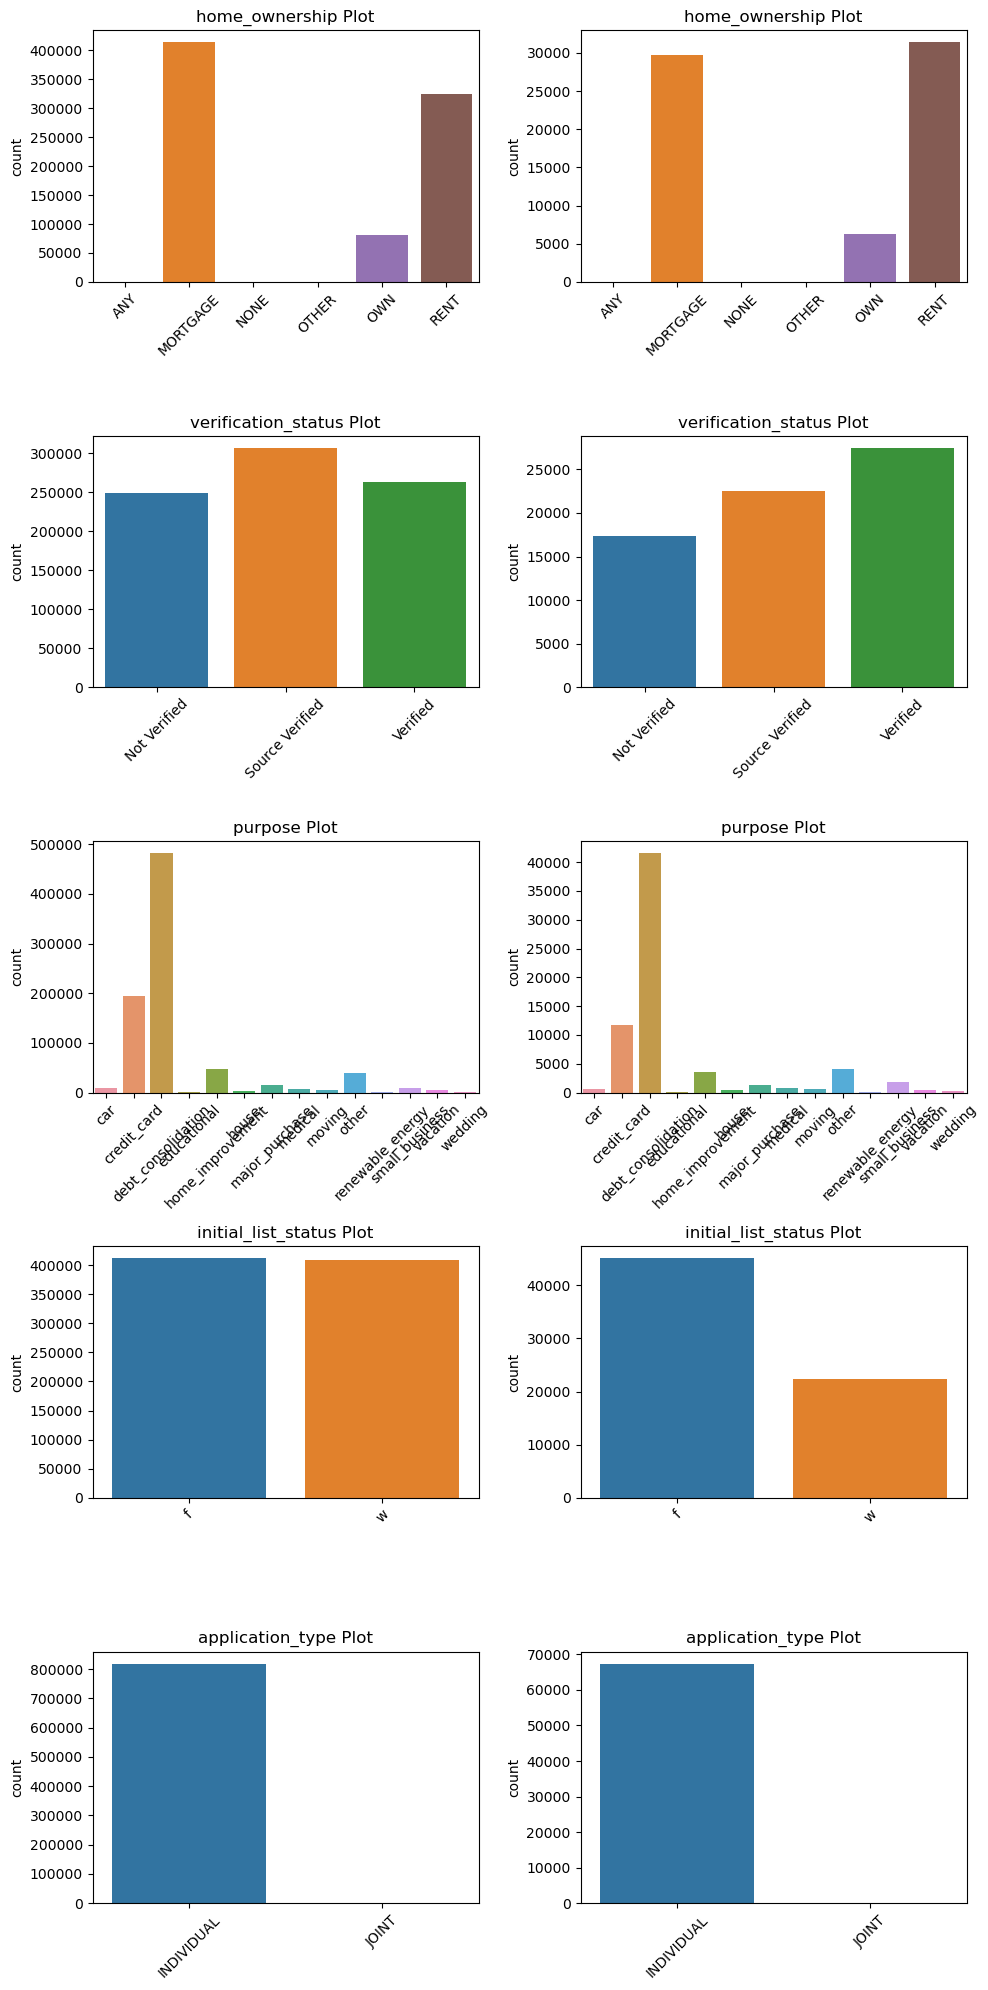

In [44]:
l=len(categorical_variables)
df0=df.loc[df['Credit_risk']==0]
df1=df.loc[df['Credit_risk']==1]

plt.figure(figsize=(10,20))

for i in range(l):
    categories = sorted(df[categorical_variables[i]].dropna().unique())
    plt.subplot(l,2,2*i+1)
    sns.countplot(x=categorical_variables[i],data=df0, order=categories)
    plt.title(categorical_variables[i]+' Plot')
    plt.xlabel(None)
    plt.xticks(rotation=45)
    
    plt.subplot(l,2,2*i+2)
    sns.countplot(x=categorical_variables[i],data=df1, order=categories)
    plt.title(categorical_variables[i]+' Plot')
    plt.xlabel(None)
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

In [45]:
for col in categorical_variables:
    print(str(col) + " : ")
    temp=(df.groupby([col,'Credit_risk']).size().unstack(fill_value=0).reset_index())
    temp['Total'] = temp[0] + temp[1]
    temp['%Credit_0'] = (temp[0] / temp['Total'] * 100).round(2)
    temp['%Credit_1'] = (temp[1] / temp['Total'] * 100).round(2)
    temp=temp[[col,'Total','%Credit_0','%Credit_1']]
    summary_df = pd.DataFrame(temp)
    print(temp)

home_ownership : 
Credit_risk home_ownership   Total  %Credit_0  %Credit_1
0                      ANY       3     100.00       0.00
1                 MORTGAGE  443557      93.30       6.70
2                     NONE      50      84.00      16.00
3                    OTHER     182      79.12      20.88
4                      OWN   87470      92.81       7.19
5                     RENT  356117      91.19       8.81
verification_status : 
Credit_risk verification_status   Total  %Credit_0  %Credit_1
0                  Not Verified  266750      93.48       6.52
1               Source Verified  329558      93.16       6.84
2                      Verified  291071      90.55       9.45
purpose : 
Credit_risk             purpose   Total  %Credit_0  %Credit_1
0                           car    8863      93.28       6.72
1                   credit_card  206182      94.30       5.70
2            debt_consolidation  524215      92.06       7.94
3                   educational     423      79.20   

1. Here we can see that for home_ownership, morgage payments have lesser credit risk compared to people have rented of own their home
2. Verified customers have higher credit risk than the non-verified ones
3. Purpose also shows wide variety of credit risk compared to each other
4. Joint applications have lesser credit risk but the numbers of such applications is also less

In [46]:
df.dtypes

loan_amnt              float64
term_month             float64
int_rate               float64
installment            float64
emp_length             float64
home_ownership          object
annual_inc             float64
verification_status     object
purpose                 object
initial_list_status     object
application_type        object
Credit_risk              int64
grade_num                int64
dtype: object

### For numerical Variables creating box plot and Correlation Heatmap

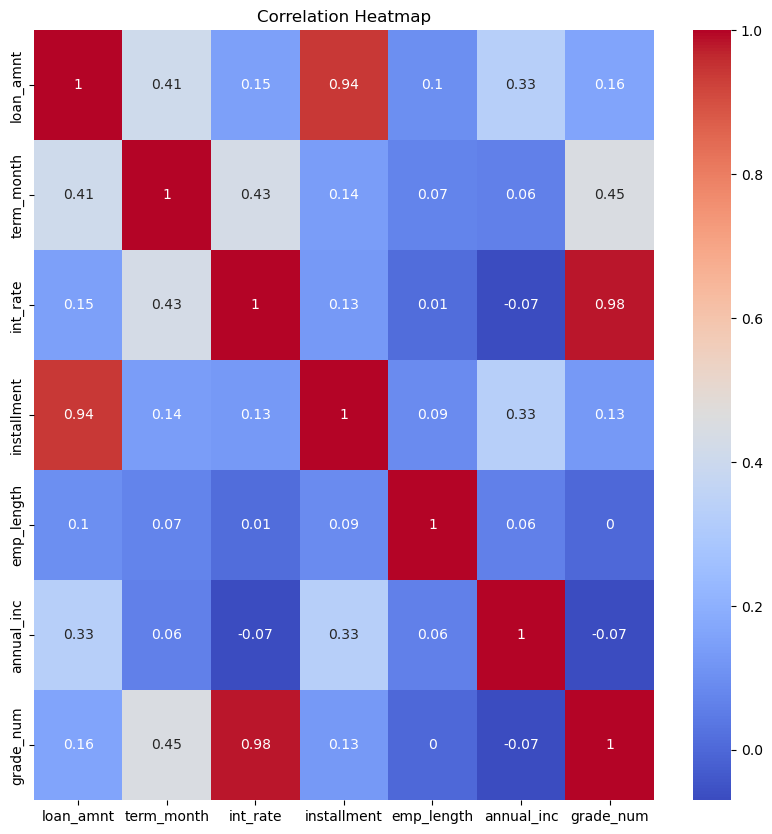

In [47]:
correlation=df_numerical.corr().round(2)
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cmap='coolwarm',cbar=True)
plt.title("Correlation Heatmap")
plt.show()

1. There is a high correlation between loan amount and installment. Since loan amount is primary variable between the two, we will drop installment
1. There is a high correlation between grade_num nd int_rate. Since grade_num is primary variable between the two, we will drop int_rate

In [48]:
df.drop('installment',axis=1,inplace=True)
df.drop('int_rate',axis=1,inplace=True)

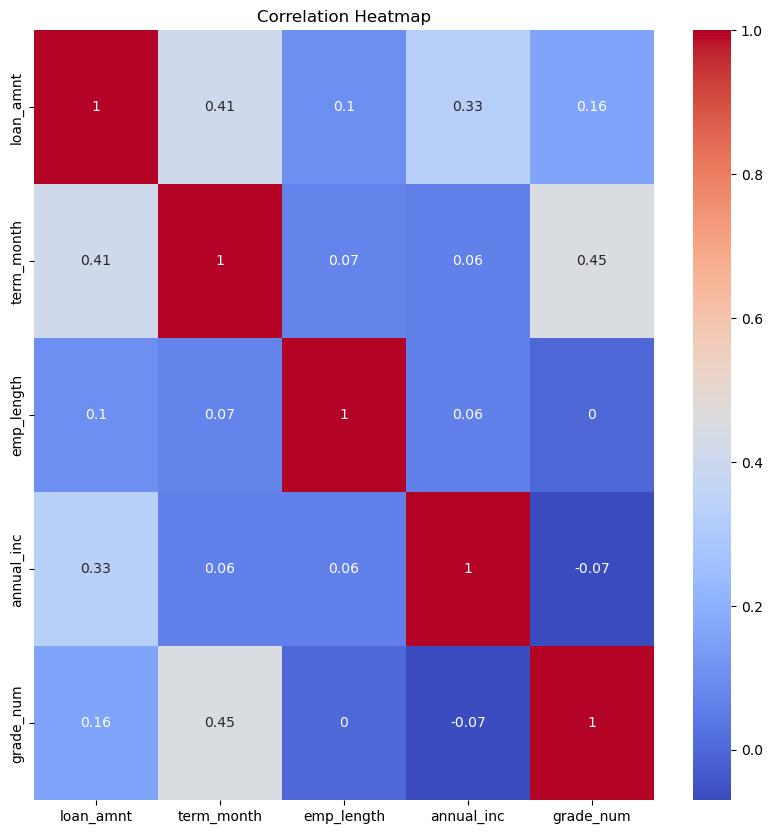

In [49]:
df_categorical,df_numerical,categorical_variables,numerical_variables=cat_num_split(df)
correlation=df_numerical.corr().round(2)
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cmap='coolwarm',cbar=True)
plt.title("Correlation Heatmap")
plt.show()

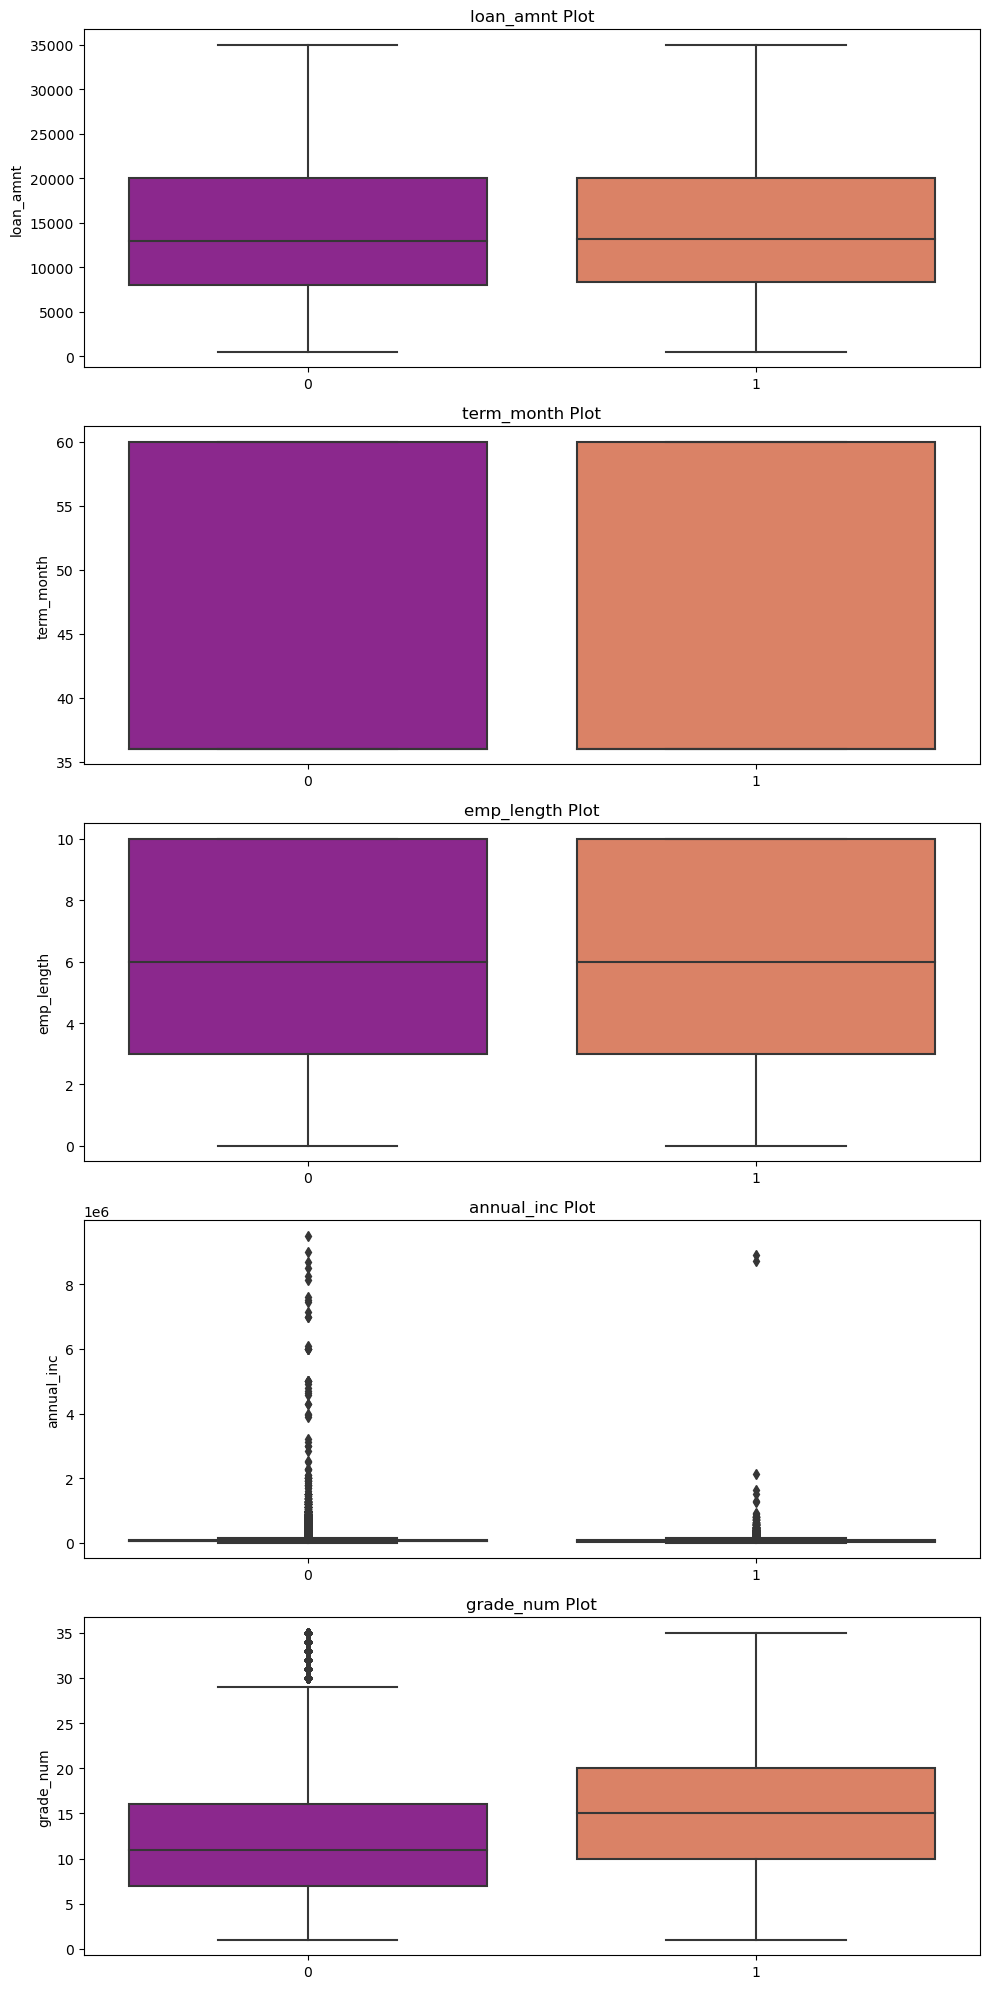

In [50]:
l=len(numerical_variables)

plt.figure(figsize=(10,20))

for i in range(l):
    plt.subplot(l,1,i+1)
    sns.boxplot(x=df.Credit_risk,y=df[numerical_variables[i]],palette=("plasma"))
    plt.title(numerical_variables[i]+' Plot')
    plt.xlabel(None)
    
plt.tight_layout()
plt.show()

## Data Scaling and Dummy Variables

In [51]:
from sklearn.preprocessing import MinMaxScaler

In [52]:
scaler=MinMaxScaler()
numerical_variables=[i for i in numerical_variables]
df[numerical_variables]=scaler.fit_transform(df[numerical_variables])

In [53]:
l=len(categorical_variables)

for i in range(l):
    temp=pd.get_dummies(df[categorical_variables[i]],drop_first=True,prefix=categorical_variables[i],prefix_sep='_')
    df=pd.concat([df,temp],axis=1)
    df.drop(categorical_variables[i],axis=1,inplace=True)

In [54]:
df.head()

,loan_amnt,term_month,emp_length,annual_inc,Credit_risk,grade_num,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_JOINT
0,0.130435,0.0,1.0,0.002526,0,0.176471,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0.057971,1.0,0.0,0.003158,1,0.382353,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.055072,0.0,1.0,0.001290,0,0.411765,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0.275362,0.0,1.0,0.005179,0,0.294118,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0.072464,1.0,0.1,0.008421,0,0.264706,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [55]:
df.shape

(887379, 28)

## Train test Split

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
np.random.seed(20)

In [58]:
df_train,df_test=train_test_split(df,train_size=0.7,test_size=0.3,random_state=100)

In [59]:
y_train=df_train.pop('Credit_risk')
x_train=df_train

In [60]:
y_test=df_test.pop('Credit_risk')
x_test=df_test

## Model Building

In [61]:
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

In [62]:
from sklearn.metrics import confusion_matrix,roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [63]:
x_train_sample = x_train.sample(10000)
y_train_sample = y_train.loc[x_train_sample.index]
x_test_sample = x_test.sample(5000)
y_test_sample = y_test.loc[x_test_sample.index]

In [64]:
max_score=0
max_k=1

for k in range(1,200):
    n=KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    n.fit(x_train_sample,y_train_sample)
    y_pred_sample=n.predict(x_test_sample)
    score= accuracy_score(y_test_sample,y_pred_sample)
    if score>max_score:
        max_score=score
        max_k=k

In [65]:
print('Max Score : '+str(max_score))
print('K used : '+str(max_k))

Max Score : 0.9234
K used : 12


In [66]:
n=KNeighborsClassifier(n_neighbors=12)
n.fit(x_train,y_train)
y_pred=n.predict(x_test)
score= accuracy_score(y_test,y_pred)

In [67]:
print("Accuracy :", score)

Accuracy : 0.9235051499921116
